In [5]:
import numpy as np
import pickle # 导入 pickle 模块
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys
sys.path.append(r"./main_code")
import draw,generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix,kidney_data,sign,smooth,true_bound
import matplotlib.pyplot as plt

cuda:0


In [6]:
def kidney_curve(x, y, h, k, a):
    """
    计算给定点 (x, y) 的肾形线隐式函数值。
    
    参数:
    x, y: 输入的坐标点。
    h, k: 肾形线中心的坐标 (用于平移)。
    a:    肾形线的尺寸参数。
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # 避免当 a=0 时出现问题
    if a == 0:
        a = 1e-9

    # 肾形线的隐式方程: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. 主高斯源 (模拟肿瘤)
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """肾形源项函数"""
    x = X[:, 0]
    y = X[:, 1]
    # 肾形源（平移+缩放）
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """改进后的复杂源项函数"""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # 肾形源（平移+缩放）
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss



## noise=5%

In [7]:
import pickle

with open("./noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_num_proce=np.load("./noise=5%/S_num_store_ada.npy")
S_num_last=S_num_proce[-1]
# 创建数据


In [8]:
kidney_bound=np.load("./noise=5%/kidney_num.npy")

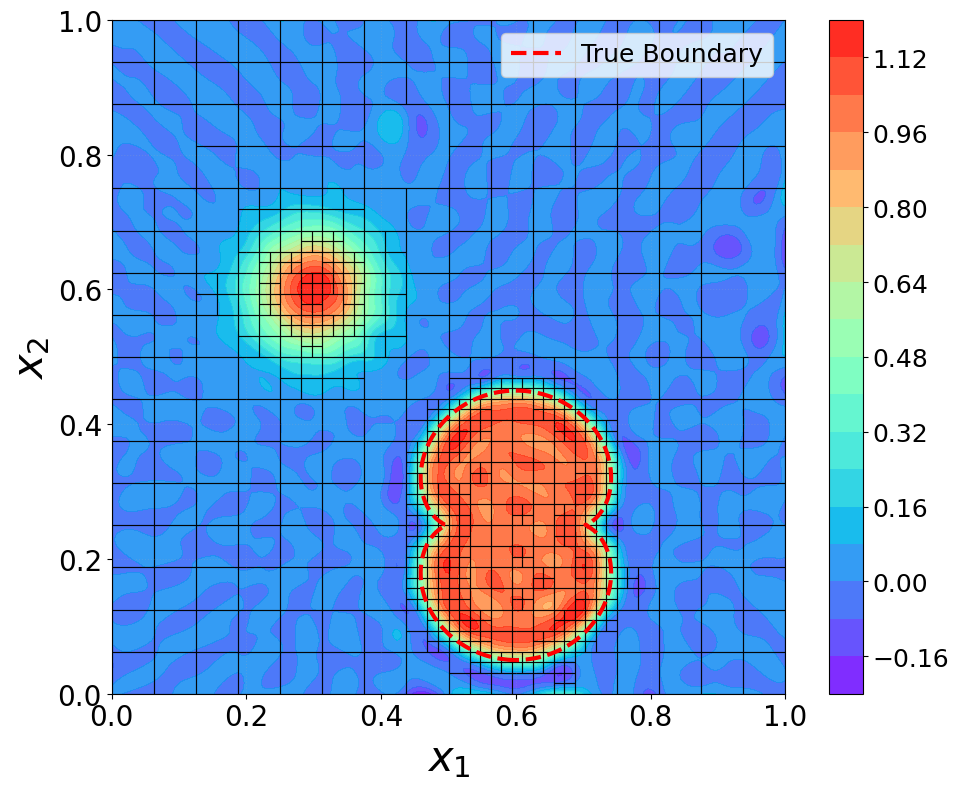

In [9]:
import gridlook
reload(gridlook)
reload(true_bound)
v=gridlook.MeshVisualizer()
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 8))
fig1=v._plot_single_mesh(fig1, ax1, cells_store, 
                       S_num=S_num_last, points=samples, save_path=None)

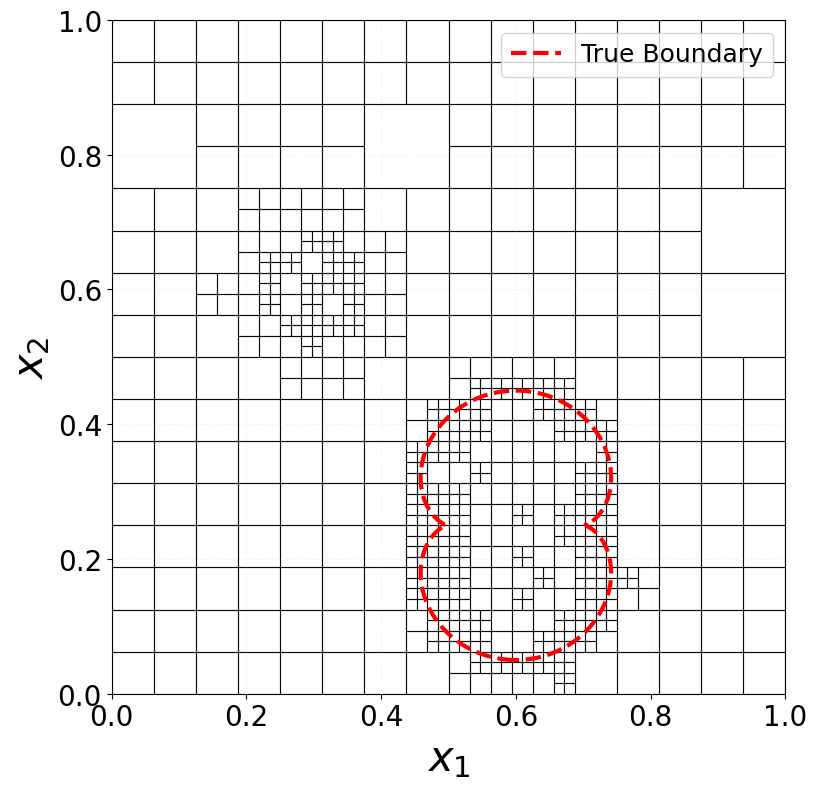

In [10]:
import gridlook
reload(gridlook)
reload(true_bound)
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
fig2=v._plot_single_mesh(fig2, ax2, cells_store, save_path=None)

/data5/store1/hxw/code/Ex4.6/./main_code/true_bound.py:51: RuntimeWarning: overflow encountered in exp
  z_flat = 1 / (1 + np.exp(K * signed_distances))


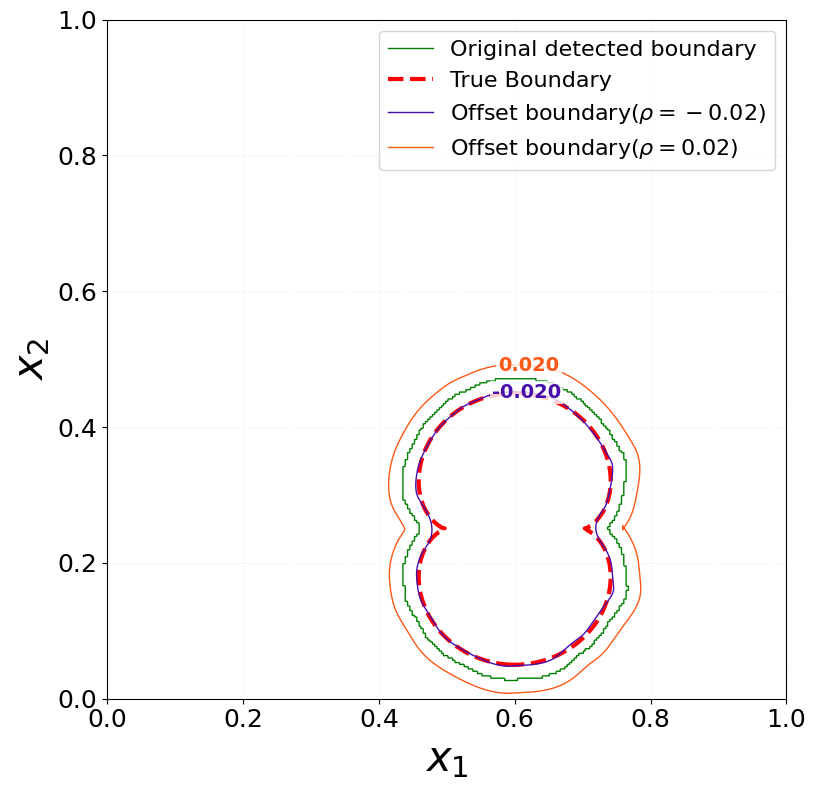

In [11]:
import gridlook
reload(gridlook)
reload(true_bound)
v=gridlook.MeshVisualizer()
fig3, ax3 = plt.subplots(1, 1, figsize=(10, 8))
fig3=v._scale(fig3, ax3,kidney_bound)

In [12]:
#保存fig1
fig1.savefig("./noise=5%/kidney_value.pdf", dpi=300)
fig2.savefig("./noise=5%/kidney_mesh.pdf", dpi=300)
fig3.savefig("./noise=5%/scale_boundary.pdf", dpi=300)

Plot saved as ./noise=5%/S_true.pdf


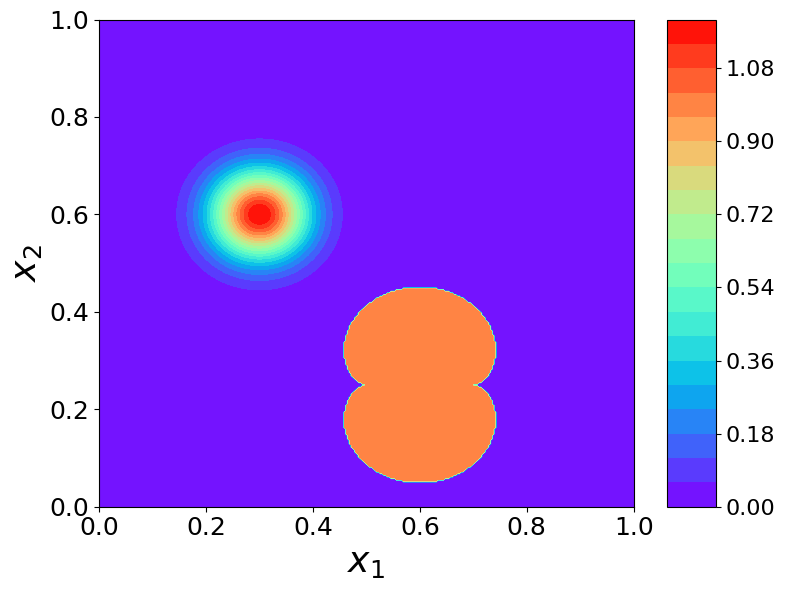

Plot saved as ./noise=5%/S_num_last.pdf


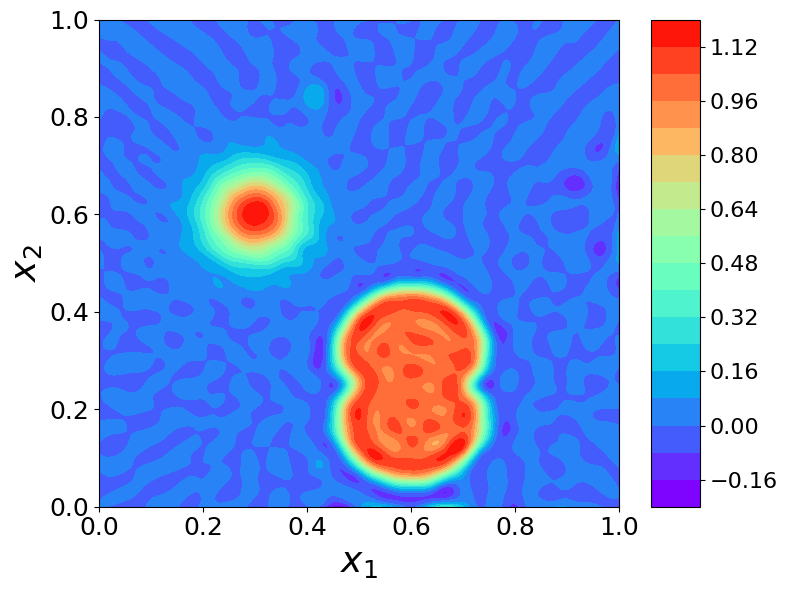

Plot saved as ./noise=5%/abs_S.pdf


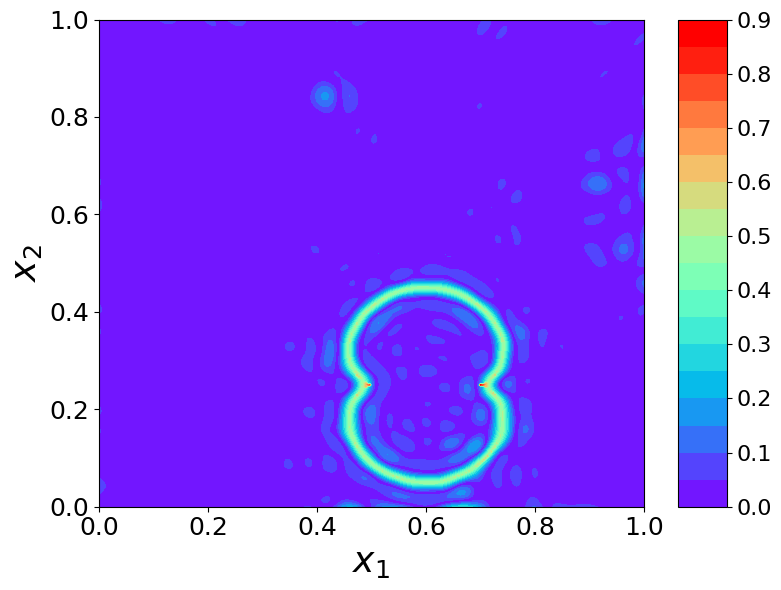

In [15]:
S_num_proce=np.load("./noise=5%/S_num_store_ada.npy")
S_num_last=S_num_proce[-1]
# 创建数据

S_true=elegant_source(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./noise=5%/"
draw.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
draw.draw(X,Y,S_num_last,output_dictionary,"S_num_last.pdf")
draw.draw(X,Y,np.abs(S_true-S_num_last),output_dictionary,"abs_S.pdf")

Plot saved as ./noise=5%/S_true.pdf


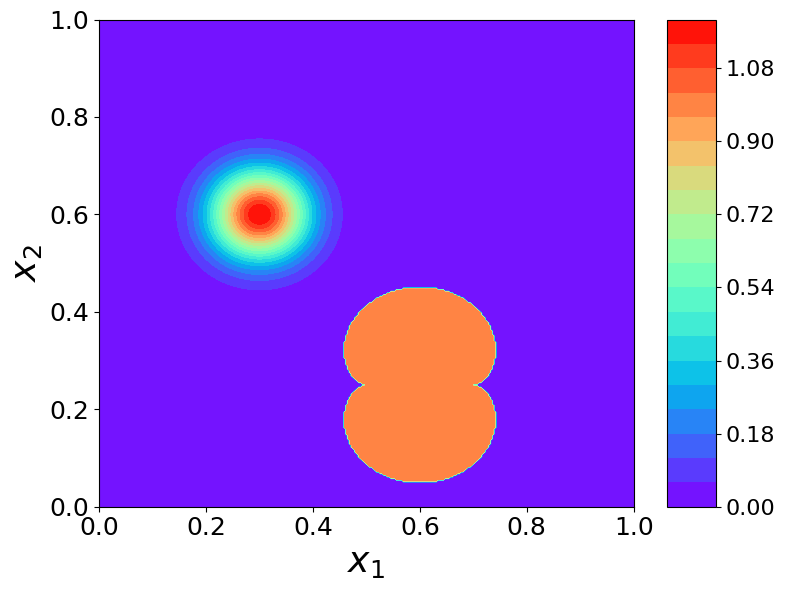

Plot saved as ./noise=5%/S_num.pdf


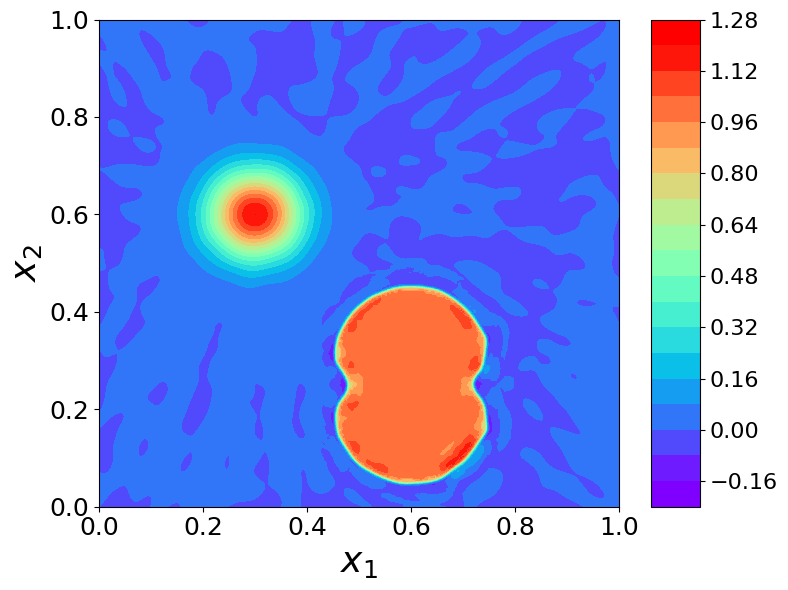

Plot saved as ./noise=5%/abs_S.pdf


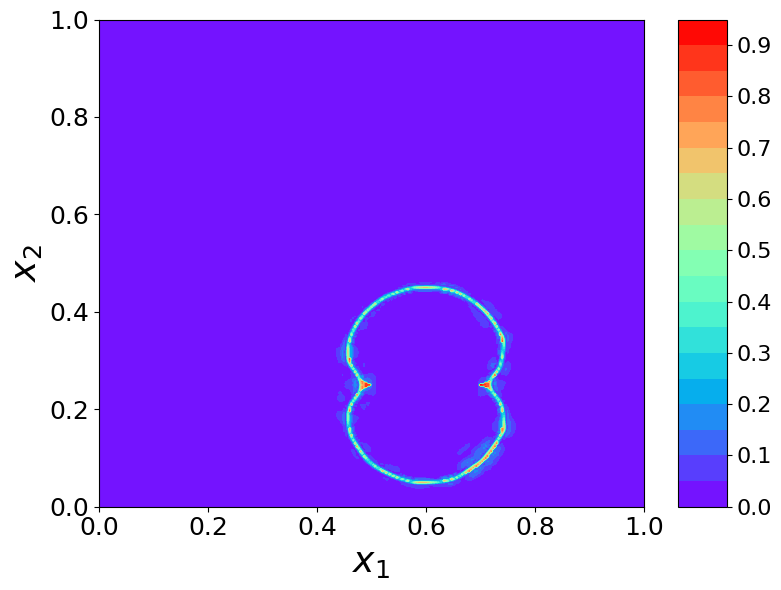

In [17]:
S_num=np.load("./noise=5%/S_test_num.npy")
# 创建数据
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_true=elegant_source(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./noise=5%/"
draw.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
draw.draw(X,Y,S_num,output_dictionary,"S_num.pdf")
draw.draw(X,Y,np.abs(S_true-S_num),output_dictionary,"abs_S.pdf")